In [1]:
# Cell 1: Imports and config
import os, re
import numpy as np
import pandas as pd

log_dir = 'log_outputs'
out_dir = 'log_summaries'
os.makedirs(out_dir, exist_ok=True)

datasets = ['wisdm', 'har', 'grabmyo','dailysports','uwave']
ratios = [0.50, 0.35, 0.20]
samplers = ['uncertainty_diversity', 'typi_clust']
oods = ['msp', 'mahalanobis', 'energy', 'none']
models_order = [f'{s}_{o}' for s in samplers for o in oods]

fname_re = re.compile(
    r'^CNN_(?P<dataset>[^_]+)_(?P<sampler>uncertainty_diversity|typi_clust)_(?P<ood>msp|mahalanobis|energy|none)_(?P<ratio>\d+(?:\.\d+)?)_log\.txt$'
)
metrics_re = re.compile(
    r'Avg_End_Acc\s*\[(?P<end>[-\d\.]+)\]\s*'
    r'Avg_End_Fgt\s*\[(?P<fgt>[-\d\.]+)\]\s*'
    r'Avg_Cur_Acc\s*\[(?P<cur>[-\d\.]+)\]\s*'
    r'Avg_Acc\s*\[\[(?P<acc_vec>[^\]]+)\]\]\s*'
    r'Avg_Bwtp\s*\[(?P<bwtp>[-\d\.]+)\]'
)
def norm_ratio(rstr: str) -> str:
    try:
        return f'{float(rstr):.2f}'
    except:
        return rstr

def parse_last_metrics(path: str):
    last = ''
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            if 'Avg_End_Acc' in line and 'Avg_Acc' in line:
                last = line.strip()
    m = metrics_re.search(last)
    if not m:
        return None
    end = float(m.group('end'))
    fgt = float(m.group('fgt'))
    cur = float(m.group('cur'))
    acc_vec_str = m.group('acc_vec')
    acc_vals = [float(x) for x in acc_vec_str.split() if x.replace('.','',1).replace('-','',1).isdigit()]
    acc_mean = float(np.mean(acc_vals)) if acc_vals else np.nan
    return {
        'Avg_End_Acc': end,
        'Avg_End_Fgt': fgt,
        'Avg_Cur_Acc': cur,
        'Avg_Acc': acc_mean,
        'Avg_Acc_vec': acc_vals,
    }

# Cell 2: Collect metrics and build DataFrames
# Structure: results[(dataset, ratio_str)][model_name] = metrics dict
results = {}

for fname in os.listdir(log_dir):
    if not fname.endswith('.txt'):
        continue
    m = fname_re.match(fname)
    if not m:
        # Skip files not following the naming convention
        continue
    ds = m.group('dataset')
    sampler = m.group('sampler')
    ood = m.group('ood')
    ratio_s = norm_ratio(m.group('ratio'))
    if ds not in datasets:
        continue
    path = os.path.join(log_dir, fname)
    metrics = parse_last_metrics(path)
    if not metrics:
        continue
    key = (ds, ratio_s)
    model = f'{sampler}_{ood}'
    results.setdefault(key, {})[model] = metrics

# Build the 9 DataFrames and save
dfs = {}
for ds in datasets:
    for r in [f'{x:.2f}' for x in ratios]:
        key = (ds, r)
        # Initialize DF with metric rows and model columns in fixed order
        df = pd.DataFrame(index=['Avg_End_Acc','Avg_End_Fgt','Avg_Cur_Acc','Avg_Acc'], columns=models_order, dtype=float)
        for model in models_order:
            if key in results and model in results[key]:
                vals = results[key][model]
                df.loc['Avg_End_Acc', model] = vals['Avg_End_Acc']
                df.loc['Avg_End_Fgt', model] = vals['Avg_End_Fgt']
                df.loc['Avg_Cur_Acc', model] = vals['Avg_Cur_Acc']
                df.loc['Avg_Acc', model] = vals['Avg_Acc']
        df = df.round(2)
        dfs[key] = df
        out_csv = os.path.join(out_dir, f'{ds}_{r}_summary.csv')
        df.to_csv(out_csv, index=True)

# Cell 3: Example display (adjust as needed)
display_key = ('wisdm', '0.50')
if display_key in dfs:
    print(f'Dataset {display_key[0]} OOD ratio {display_key[1]}')
    display(dfs[display_key])
else:
    print('Requested DF not found. Available keys:', sorted(dfs.keys()))

Dataset wisdm OOD ratio 0.50


,uncertainty_diversity_msp,uncertainty_diversity_mahalanobis,uncertainty_diversity_energy,uncertainty_diversity_none,typi_clust_msp,typi_clust_mahalanobis,typi_clust_energy,typi_clust_none
Avg_End_Acc,51.35,48.05,51.51,53.44,52.65,48.71,45.68,51.01
Avg_End_Fgt,21.03,24.53,21.29,15.07,16.76,22.62,18.39,13.67
Avg_Cur_Acc,65.16,64.69,65.45,62.68,64.55,65.58,60.06,59.73
Avg_Acc,66.42,63.10,65.46,66.86,66.39,64.89,62.38,65.64


# End statistics

In [2]:
# Cell: Styled display of all DataFrames with group-wise highlights (outline only)
import numpy as np
from IPython.display import display

def highlight_group_winners(s):
    cols = list(s.index)
    styles = [''] * len(cols)
    groups = {
        'uncertainty_diversity_': [i for i, c in enumerate(cols) if c.startswith('uncertainty_diversity_')],
        'typi_clust_': [i for i, c in enumerate(cols) if c.startswith('typi_clust_')],
    }
    for _, idxs in groups.items():
        if not idxs:
            continue
        vals = np.array([s.iloc[i] for i in idxs], dtype=float)
        if s.name == 'Avg_End_Fgt':
            target = np.nanmin(vals)
        else:
            target = np.nanmax(vals)
        winners = [idxs[i] for i, v in enumerate(vals) if np.isfinite(v) and np.isclose(v, target, rtol=1e-5, atol=1e-8)]
        for j in winners:
            styles[j] = 'border: 2px solid #6fa8dc;'  # outline only, light blue
    return styles

for ds in datasets:
    for r in [f'{x:.2f}' for x in ratios]:
        key = (ds, r)
        print(f'=== Dataset: {ds} | OOD ratio: {r} ===')
        if key in dfs:
            display(dfs[key].style.apply(highlight_group_winners, axis=1).format('{:.2f}'))
        else:
            print('No data available.\n')

=== Dataset: wisdm | OOD ratio: 0.50 ===


,uncertainty_diversity_msp,uncertainty_diversity_mahalanobis,uncertainty_diversity_energy,uncertainty_diversity_none,typi_clust_msp,typi_clust_mahalanobis,typi_clust_energy,typi_clust_none
Avg_End_Acc,51.35,48.05,51.51,53.44,52.65,48.71,45.68,51.01
Avg_End_Fgt,21.03,24.53,21.29,15.07,16.76,22.62,18.39,13.67
Avg_Cur_Acc,65.16,64.69,65.45,62.68,64.55,65.58,60.06,59.73
Avg_Acc,66.42,63.10,65.46,66.86,66.39,64.89,62.38,65.64


=== Dataset: wisdm | OOD ratio: 0.35 ===


,uncertainty_diversity_msp,uncertainty_diversity_mahalanobis,uncertainty_diversity_energy,uncertainty_diversity_none,typi_clust_msp,typi_clust_mahalanobis,typi_clust_energy,typi_clust_none
Avg_End_Acc,51.30,47.50,48.80,52.76,51.60,53.36,49.44,53.51
Avg_End_Fgt,17.20,17.55,21.78,15.94,15.02,15.79,16.51,10.84
Avg_Cur_Acc,61.77,60.22,63.28,63.50,62.28,64.75,61.36,59.70
Avg_Acc,64.75,62.05,64.41,64.77,64.35,66.57,62.94,65.77


=== Dataset: wisdm | OOD ratio: 0.20 ===


...

,uncertainty_diversity_msp,uncertainty_diversity_mahalanobis,uncertainty_diversity_energy,uncertainty_diversity_none,typi_clust_msp,typi_clust_mahalanobis,typi_clust_energy,typi_clust_none
Avg_End_Acc,73.40,85.78,86.59,84.82,71.43,76.77,73.11,69.26
Avg_End_Fgt,24.61,7.15,6.34,10.74,26.22,18.35,24.40,27.72
Avg_Cur_Acc,91.86,91.15,91.35,92.44,91.10,90.06,91.41,90.06
Avg_Acc,84.18,90.24,90.66,89.21,87.67,88.74,87.93,87.10


=== Dataset: uwave | OOD ratio: 0.35 ===


,uncertainty_diversity_msp,uncertainty_diversity_mahalanobis,uncertainty_diversity_energy,uncertainty_diversity_none,typi_clust_msp,typi_clust_mahalanobis,typi_clust_energy,typi_clust_none
Avg_End_Acc,83.96,84.30,87.00,78.95,87.98,85.20,82.36,84.59
Avg_End_Fgt,10.75,11.50,8.58,19.14,5.85,7.68,10.54,7.86
Avg_Cur_Acc,90.84,91.04,91.38,91.10,89.68,89.14,88.21,89.07
Avg_Acc,88.60,89.10,88.97,87.08,90.53,87.62,87.98,85.95


=== Dataset: uwave | OOD ratio: 0.20 ===


,uncertainty_diversity_msp,uncertainty_diversity_mahalanobis,uncertainty_diversity_energy,uncertainty_diversity_none,typi_clust_msp,typi_clust_mahalanobis,typi_clust_energy,typi_clust_none
Avg_End_Acc,82.66,79.99,72.00,82.10,84.98,80.65,85.87,76.90
Avg_End_Fgt,13.79,17.65,27.66,9.48,8.66,14.14,8.74,19.39
Avg_Cur_Acc,89.66,90.06,89.43,86.32,89.27,88.22,90.07,89.37
Avg_Acc,89.58,89.27,86.67,88.13,89.11,88.28,89.54,87.31


# New task performance

In [4]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
from pandas.io.formats.style import Styler

# Point to your CSV folder
BASE_DIR = Path("csv2_outputs")   # change if needed

# Choose which split to process
PROCESS_SPLIT = "test"            # "test", "val", or "both"

def load_matrix_csv(path: Path) -> np.ndarray:
    df = pd.read_csv(path, header=None)
    mat = df.values.astype(float)
    if mat.shape[0] != mat.shape[1]:
        raise ValueError(f"Non-square matrix in {path.name}: {mat.shape}")
    return mat

In [5]:
# Helper: diagonal series (new task accuracy at each cycle)
def compute_diag_series(mat: np.ndarray, label_prefix="task") -> pd.Series:
    n = mat.shape[0]
    diag = [mat[i, i] for i in range(n)]
    index = [f"{label_prefix}{i+1}" for i in range(n)]
    return pd.Series(diag, index=index, name="diag")

# Build the diagonal comparison sheets:
# For each (dataset, ratio[, split]), rows = task1..taskN, columns = variants
def build_diagonal_comparisons(base_dir: Path, process_split: str = "test"):
    OOD_METHODS = r"(energy|mahalanobis|msp|none)"
    SPLITS = r"(test|val)"  # change to r"(test)" if you only want test files to match
    FNAME_RE = re.compile(
        rf"^CNN_(?P<dataset>[^_]+)_(?P<model>.+)_(?P<ood>{OOD_METHODS})_(?P<ratio>[0-9.]+)_(?P<split>{SPLITS})\.csv$"
    )
    def parse_filename(fname: str):
        m = FNAME_RE.match(fname)
        if not m:
            return None
        g = m.groupdict()
        return {
            "dataset": g["dataset"].lower(),
            "model": g["model"].lower(),
            "ood_method": g["ood"].lower(),
            "ratio": float(g["ratio"]),
            "split": g["split"].lower(),
        }
    def variant_label(model: str, ood_method: str) -> str:
        return f"{model} ({ood_method})"

    diag_groups = {}  # key -> dict of {variant: series(task_i -> value)}

    for path in base_dir.glob("*.csv"):
        meta = parse_filename(path.name)
        if meta is None:
            continue
        if process_split != "both" and meta["split"] != process_split:
            continue

        try:
            mat = load_matrix_csv(path)
        except Exception as e:
            print(f"Error reading {path.name}: {e}")
            continue

        key = (meta["dataset"], meta["ratio"]) if process_split != "both" else (meta["dataset"], meta["ratio"], meta["split"])
        variant = variant_label(meta["model"], meta["ood_method"])
        diag = compute_diag_series(mat, label_prefix="task")

        if key not in diag_groups:
            diag_groups[key] = {}
        diag_groups[key][variant] = diag

    # Convert each group to a DataFrame with union of all task rows
    diag_sheets = {}
    for key, variant_to_series in diag_groups.items():
        all_index = sorted(set().union(*[s.index for s in variant_to_series.values()]),
                           key=lambda x: int(x.replace("task","")))
        df = pd.DataFrame(index=all_index)
        for variant, s in variant_to_series.items():
            df[variant] = s.reindex(all_index)
        df = df.sort_index(axis=1)  # sort columns by name for readability
        diag_sheets[key] = df

    return diag_sheets

In [6]:
BORDER_CSS = "border: 2px solid #6fa8dc;"
GREEN_TXT = "color: #1a7f37;"
RED_TXT = "color: #d73a49;"

def style_compare_vs_none(df: pd.DataFrame) -> pd.io.formats.style.Styler:
    # Parse columns into (model, ood)
    def split_col(col_name: str):
        if " (" in col_name and col_name.endswith(")"):
            base, rest = col_name.split(" (", 1)
            return base.strip(), rest[:-1].strip()
        return col_name.strip(), ""

    parsed = [split_col(c) for c in df.columns]
    oods = [p[1] for p in parsed]

    model_to_cols = {}
    none_idx_by_model = {}
    for j, (m, o) in enumerate(parsed):
        model_to_cols.setdefault(m, []).append(j)
        if o == "none":
            none_idx_by_model[m] = j

    row_names = [str(r).strip().lower() for r in df.index]
    valid_rows = [i for i, nm in enumerate(row_names) if nm not in ("task1", "task 1")]

    selected_single_by_model = {}
    for m, idxs in model_to_cols.items():
        none_idx = none_idx_by_model.get(m)
        if none_idx is None or not valid_rows:
            continue
        best = None  # (wins, avg, -col_order), col_idx
        for j in idxs:
            if oods[j] == "none":
                continue
            wins = 0
            vals = []
            for r in valid_rows:
                v = df.iat[r, j]
                b = df.iat[r, none_idx]
                if pd.notna(v):
                    vals.append(float(v))
                if pd.notna(v) and pd.notna(b) and float(v) > float(b):
                    wins += 1
            avg = np.nan if not vals else float(np.mean(vals))
            key = (wins, avg, -j)
            if best is None or key > best[0]:
                best = (key, j)
        if best is not None and best[0][0] > 0:
            selected_single_by_model[m] = best[1]

    n_cols = df.shape[1]
    def row_style(row: pd.Series):
        styles = [""] * n_cols
        rname = str(row.name).strip().lower()

        # Outline 'none' + the single selected OOD column for each model
        for m, idxs in model_to_cols.items():
            none_idx = none_idx_by_model.get(m)
            if none_idx is not None:
                styles[none_idx] = BORDER_CSS
            sel_idx = selected_single_by_model.get(m)
            if sel_idx is not None:
                styles[sel_idx] = BORDER_CSS

        if rname in ("task1", "task 1"):
            return styles

        for m, idxs in model_to_cols.items():
            none_idx = none_idx_by_model.get(m)
            sel_idx = selected_single_by_model.get(m)
            if none_idx is None or sel_idx is None:
                continue
            b = row.iat[none_idx]
            v = row.iat[sel_idx]
            if pd.notna(v) and pd.notna(b):
                if float(v) > float(b):
                    styles[sel_idx] = (styles[sel_idx] + "; " if styles[sel_idx] else "") + GREEN_TXT
                elif float(b) > float(v):
                    styles[none_idx] = (styles[none_idx] + "; " if styles[none_idx] else "") + RED_TXT
        return styles

    return df.style.apply(row_style, axis=1).format("{:.2f}")

In [7]:
diag_sheets = build_diagonal_comparisons(BASE_DIR, PROCESS_SPLIT)

for key, df in diag_sheets.items():
    if isinstance(key, tuple):
        if PROCESS_SPLIT != "both":
            ds, ratio = key
            key_str = f"dataset={ds}, ratio={ratio}"
        else:
            ds, ratio, split = key
            key_str = f"dataset={ds}, ratio={ratio}, split={split}"
    else:
        key_str = str(key)
    print(f"\n=== Diagonal Comparison (new task performance): {key_str} ===")
    display(style_compare_vs_none(df))


=== Diagonal Comparison (new task performance): dataset=dailysports, ratio=0.2 ===


,typi_clust (energy),typi_clust (mahalanobis),typi_clust (msp),typi_clust (none),uncertainty_diversity (energy),uncertainty_diversity (mahalanobis),uncertainty_diversity (msp),uncertainty_diversity (none)
task1,97.92,97.92,100.00,97.92,100.00,100.00,100.00,100.00
task2,99.58,99.17,100.00,99.58,98.33,99.58,99.58,100.00
task3,82.92,95.83,80.00,95.00,78.75,88.33,90.42,84.58
task4,95.42,95.83,89.58,95.83,91.67,84.17,95.83,97.50
task5,95.00,98.75,92.08,96.67,97.08,97.92,91.67,92.08
task6,98.75,97.08,95.42,99.58,98.33,99.58,97.92,100.00



=== Diagonal Comparison (new task performance): dataset=dailysports, ratio=0.35 ===


,typi_clust (energy),typi_clust (mahalanobis),typi_clust (msp),typi_clust (none),uncertainty_diversity (energy),uncertainty_diversity (mahalanobis),uncertainty_diversity (msp),uncertainty_diversity (none)
task1,100.00,100.00,100.00,100.00,100.00,100.00,98.33,100.00
task2,97.92,99.58,96.67,98.75,99.17,97.08,98.33,99.17
task3,90.83,94.58,87.50,90.42,77.50,85.83,92.08,77.92
task4,95.83,97.92,83.33,97.92,96.67,91.67,89.17,92.08
task5,94.58,94.17,94.17,92.50,89.17,93.75,92.92,90.83
task6,99.17,100.00,93.75,96.67,99.58,96.67,95.42,95.42



=== Diagonal Comparison (new task performance): dataset=dailysports, ratio=0.5 ===


...

,typi_clust (energy),typi_clust (mahalanobis),typi_clust (msp),typi_clust (none),uncertainty_diversity (energy),uncertainty_diversity (mahalanobis),uncertainty_diversity (msp),uncertainty_diversity (none)
task1,53.33,53.33,53.33,62.22,54.81,54.81,54.81,54.81
task2,78.40,77.66,75.15,83.73,83.14,75.15,82.10,82.25
task3,68.40,59.79,71.81,67.36,61.42,62.61,65.28,59.94
task4,78.42,66.41,83.43,68.09,71.12,76.14,62.61,80.09
task5,47.90,53.89,71.26,63.92,50.75,62.43,48.80,52.25
task6,65.36,48.49,64.91,68.98,61.30,59.04,59.94,61.75



=== Diagonal Comparison (new task performance): dataset=wisdm, ratio=0.35 ===


,typi_clust (energy),typi_clust (mahalanobis),typi_clust (msp),typi_clust (none),uncertainty_diversity (energy),uncertainty_diversity (mahalanobis),uncertainty_diversity (msp),uncertainty_diversity (none)
task1,69.49,69.49,69.49,69.49,67.80,67.80,67.80,67.80
task2,71.89,78.55,72.49,78.11,79.44,73.37,74.26,77.37
task3,58.42,68.41,60.06,62.00,61.25,61.85,59.02,65.87
task4,68.03,65.30,66.21,57.58,65.30,63.94,64.39,62.58
task5,47.60,53.14,53.89,39.97,48.20,40.27,48.65,48.05
task6,52.71,53.61,51.51,51.05,57.68,54.07,56.48,59.34



=== Diagonal Comparison (new task performance): dataset=wisdm, ratio=0.5 ===


,typi_clust (energy),typi_clust (mahalanobis),typi_clust (msp),typi_clust (none),uncertainty_diversity (energy),uncertainty_diversity (mahalanobis),uncertainty_diversity (msp),uncertainty_diversity (none)
task1,73.59,73.59,73.59,73.59,67.06,67.06,67.06,67.06
task2,72.71,75.07,78.02,75.52,76.70,78.91,74.34,79.06
task3,62.37,59.52,70.01,62.52,67.62,63.87,69.42,68.82
task4,58.76,72.81,64.20,56.50,61.78,62.24,69.64,56.95
task5,41.59,59.91,57.21,43.39,59.16,59.46,56.61,52.55
task6,51.35,52.55,44.29,46.85,60.36,56.61,53.90,51.65


In [8]:
# task1-5 avg as CurAve 

# After you have: diag_sheets = build_diagonal_comparisons(BASE_DIR, PROCESS_SPLIT)

def make_curave_only(diag_sheets: dict):
    cur_only = {}
    for key, df in diag_sheets.items():
        # Select task rows
        task_rows = [r for r in df.index if str(r).lower().startswith('task')]
        if not task_rows:
            continue
        df_num = df.apply(pd.to_numeric, errors='coerce')
        cur_ave = df_num.loc[task_rows].mean(axis=0)
        cur_only[key] = pd.DataFrame([cur_ave], index=['CurAve'])
    return cur_only

curave_sheets = make_curave_only(diag_sheets)

from IPython.display import display
import numpy as np

def style_group_max(df):
    # Columns look like: "typi_clust (energy)" etc.
    cols = list(df.columns)
    base_models = {}
    for i, c in enumerate(cols):
        base = c.split(' (')[0].strip()
        base_models.setdefault(base, []).append(i)
    n_cols = len(cols)
    def row_style(row):
        styles = [''] * n_cols
        # Only CurAve row exists, but keep generic
        for base, idxs in base_models.items():
            vals = np.array([row.iloc[j] for j in idxs], dtype=float)
            if np.all(np.isnan(vals)):
                continue
            target = np.nanmax(vals)
            winners = [idxs[k] for k,v in enumerate(vals) if np.isfinite(v) and np.isclose(v, target, rtol=1e-5, atol=1e-8)]
            for j in winners:
                styles[j] = 'border:2px solid #6fa8dc;'  # light outline
        return styles
    return df.style.apply(row_style, axis=1).format('{:.2f}')

# Display CurAve-only tables
for key, df in curave_sheets.items():
    if isinstance(key, tuple):
        if PROCESS_SPLIT != "both":
            ds, ratio = key
            key_str = f"dataset={ds}, ratio={ratio}"
        else:
            ds, ratio, split = key
            key_str = f"dataset={ds}, ratio={ratio}, split={split}"
    else:
        key_str = str(key)
    print(f"\n=== CurAve (task mean): {key_str} ===")
    display(style_group_max(df))


=== CurAve (task mean): dataset=dailysports, ratio=0.2 ===


,typi_clust (energy),typi_clust (mahalanobis),typi_clust (msp),typi_clust (none),uncertainty_diversity (energy),uncertainty_diversity (mahalanobis),uncertainty_diversity (msp),uncertainty_diversity (none)
CurAve,94.93,97.43,92.85,97.43,94.03,94.93,95.90,95.69



=== CurAve (task mean): dataset=dailysports, ratio=0.35 ===


,typi_clust (energy),typi_clust (mahalanobis),typi_clust (msp),typi_clust (none),uncertainty_diversity (energy),uncertainty_diversity (mahalanobis),uncertainty_diversity (msp),uncertainty_diversity (none)
CurAve,96.39,97.71,92.57,96.04,93.68,94.17,94.38,92.57



=== CurAve (task mean): dataset=dailysports, ratio=0.5 ===


...

,typi_clust (energy),typi_clust (mahalanobis),typi_clust (msp),typi_clust (none),uncertainty_diversity (energy),uncertainty_diversity (mahalanobis),uncertainty_diversity (msp),uncertainty_diversity (none)
CurAve,65.30,59.93,69.98,69.05,63.76,65.03,62.26,65.18



=== CurAve (task mean): dataset=wisdm, ratio=0.35 ===


,typi_clust (energy),typi_clust (mahalanobis),typi_clust (msp),typi_clust (none),uncertainty_diversity (energy),uncertainty_diversity (mahalanobis),uncertainty_diversity (msp),uncertainty_diversity (none)
CurAve,61.36,64.75,62.27,59.70,63.28,60.22,61.77,63.50



=== CurAve (task mean): dataset=wisdm, ratio=0.5 ===


,typi_clust (energy),typi_clust (mahalanobis),typi_clust (msp),typi_clust (none),uncertainty_diversity (energy),uncertainty_diversity (mahalanobis),uncertainty_diversity (msp),uncertainty_diversity (none)
CurAve,60.06,65.58,64.55,59.73,65.45,64.69,65.16,62.68


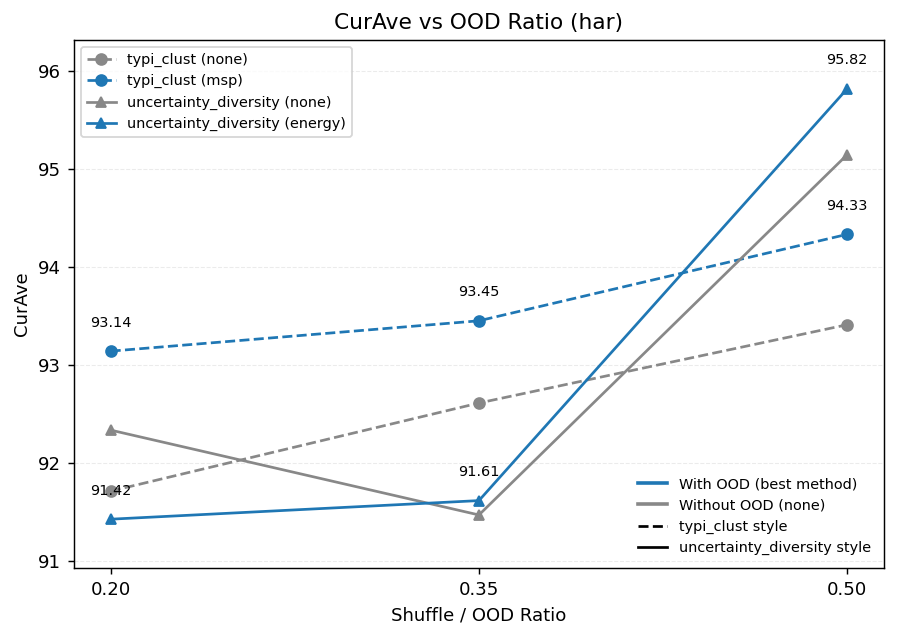

Saved result/plots/curave_ood_compare\CurAve_OOD_Comparison_har_zoomed.png (best typi_clust OOD=msp, best uncertainty OOD=energy)


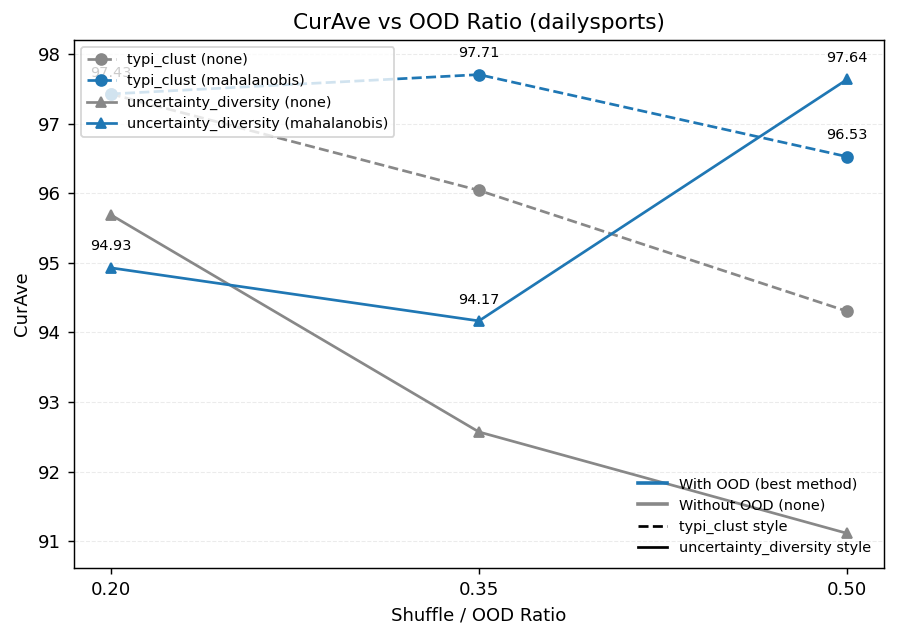

Saved result/plots/curave_ood_compare\CurAve_OOD_Comparison_dailysports_zoomed.png (best typi_clust OOD=mahalanobis, best uncertainty OOD=mahalanobis)


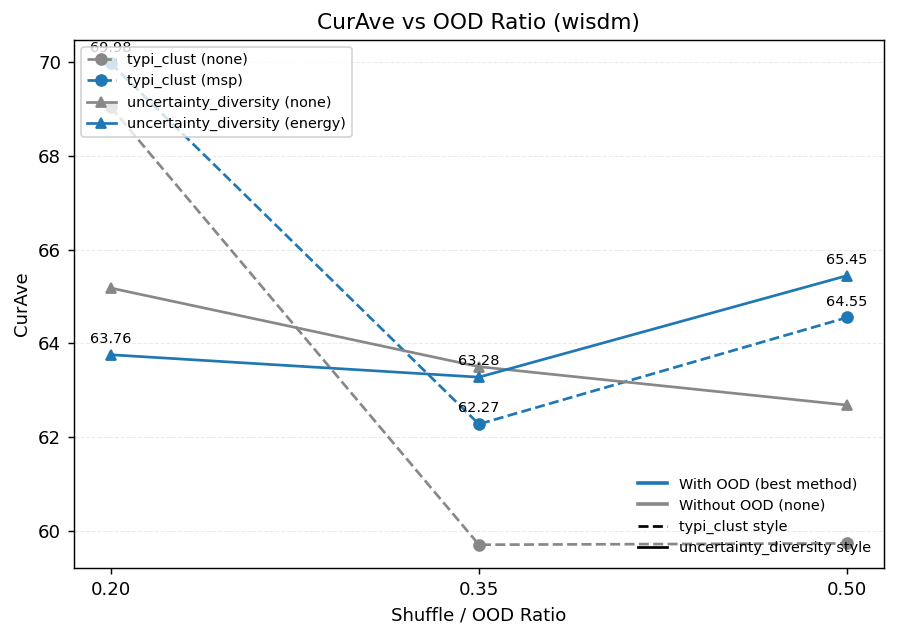

Saved result/plots/curave_ood_compare\CurAve_OOD_Comparison_wisdm_zoomed.png (best typi_clust OOD=msp, best uncertainty OOD=energy)


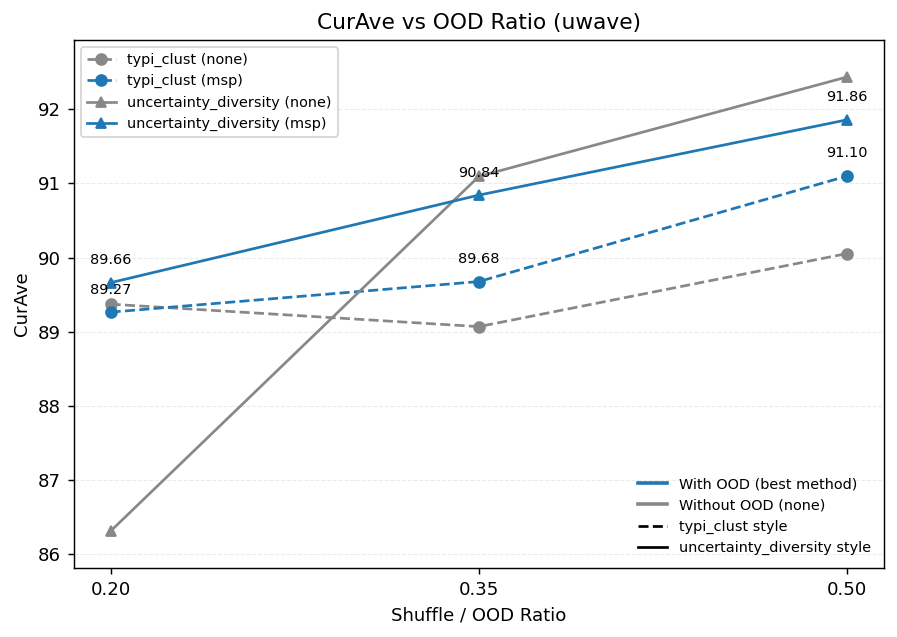

Saved result/plots/curave_ood_compare\CurAve_OOD_Comparison_uwave_zoomed.png (best typi_clust OOD=msp, best uncertainty OOD=msp)


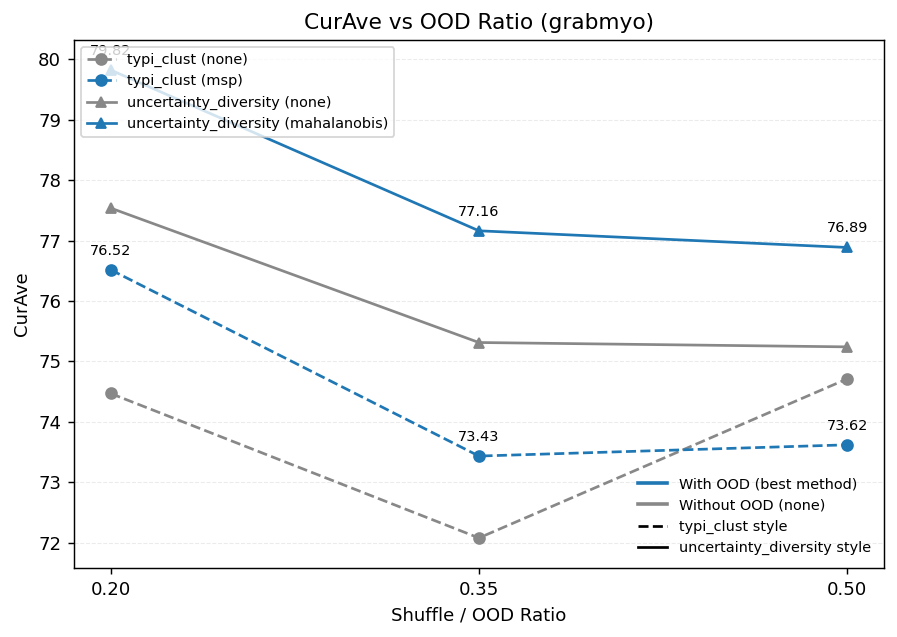

Saved result/plots/curave_ood_compare\CurAve_OOD_Comparison_grabmyo_zoomed.png (best typi_clust OOD=msp, best uncertainty OOD=mahalanobis)


In [12]:
# ...existing code...
def plot_curave_comparison(curave_sheets, datasets=('har','dailysports','wisdm','uwave','grabmyo'),
                           ratios=(0.2,0.35,0.5), save_dir="result/plots/curave_ood_compare",
                           zoom=True, min_padding=0.5, min_span=2.0):
    os.makedirs(save_dir, exist_ok=True)
    for ds in datasets:
        series_by_ratio = extract_curave(curave_sheets, ds, ratios)
        if not series_by_ratio:
            print(f"Skip {ds}: no data")
            continue
        best_tc = pick_best_ood(series_by_ratio, 'typi_clust')
        best_ud = pick_best_ood(series_by_ratio, 'uncertainty_diversity')

        r_sorted, tc_none, tc_best = build_lines(series_by_ratio, 'typi_clust', best_tc)
        _,        ud_none, ud_best = build_lines(series_by_ratio, 'uncertainty_diversity', best_ud)

        plt.figure(figsize=(7,5), dpi=130)
        color_none = '#888888'
        color_ood  = '#1f77b4'

        plt.plot(r_sorted, tc_none, '--o', color=color_none, label='typi_clust (none)')
        plt.plot(r_sorted, tc_best, '--o', color=color_ood,  label=f"typi_clust ({best_tc})")
        plt.plot(r_sorted, ud_none, '-^',  color=color_none, label='uncertainty_diversity (none)')
        plt.plot(r_sorted, ud_best, '-^',  color=color_ood,  label=f"uncertainty_diversity ({best_ud})")

        # Annotate best OOD lines
        for x,y in zip(r_sorted, tc_best):
            if np.isfinite(y):
                plt.text(x, y+0.25, f"{y:.2f}", ha='center', fontsize=8)
        for x,y in zip(r_sorted, ud_best):
            if np.isfinite(y):
                plt.text(x, y+0.25, f"{y:.2f}", ha='center', fontsize=8)

        plt.title(f"CurAve vs OOD Ratio ({ds})")
        plt.xlabel("Shuffle / OOD Ratio")
        plt.ylabel("CurAve")
        plt.xticks(r_sorted, [f"{r:.2f}" for r in r_sorted])
        plt.grid(alpha=0.25, axis='y', linestyle='--', linewidth=0.6)

        # Zoomed y-axis
        if zoom:
            all_vals = np.array(tc_none + tc_best + ud_none + ud_best, dtype=float)
            all_vals = all_vals[np.isfinite(all_vals)]
            if all_vals.size:
                vmin, vmax = float(all_vals.min()), float(all_vals.max())
                span = vmax - vmin
                if span < min_span:
                    # Enforce a minimal span for visibility
                    center = (vmin + vmax)/2
                    half = max(min_span/2, span/2 + min_padding)
                    vmin, vmax = center - half, center + half
                else:
                    vmin -= min_padding
                    vmax += min_padding
                vmin = max(0, vmin)
                vmax = min(100, vmax)
                if vmin == vmax:
                    vmax = min(100, vmin + 1)
                plt.ylim(vmin, vmax)
        else:
            plt.ylim(0, 100)

        extra_lines = [
            plt.Line2D([0],[0], color=color_ood,  lw=2, label='With OOD (best method)'),
            plt.Line2D([0],[0], color=color_none,lw=2, label='Without OOD (none)'),
            plt.Line2D([0],[0], color='black', linestyle='--', label='typi_clust style'),
            plt.Line2D([0],[0], color='black', linestyle='-',  label='uncertainty_diversity style')
        ]
        leg1 = plt.legend(loc='upper left', fontsize=8)
        plt.legend(handles=extra_lines, loc='lower right', fontsize=8, frameon=False)
        plt.gca().add_artist(leg1)

        out_path = os.path.join(save_dir, f"CurAve_OOD_Comparison_{ds}_zoomed.png")
        plt.tight_layout()
        plt.savefig(out_path, bbox_inches='tight')
        plt.show()
        print(f"Saved {out_path} (best typi_clust OOD={best_tc}, best uncertainty OOD={best_ud})")

# Re-run to regenerate zoomed plots
plot_curave_comparison(curave_sheets, zoom=True)
# ...existing code...

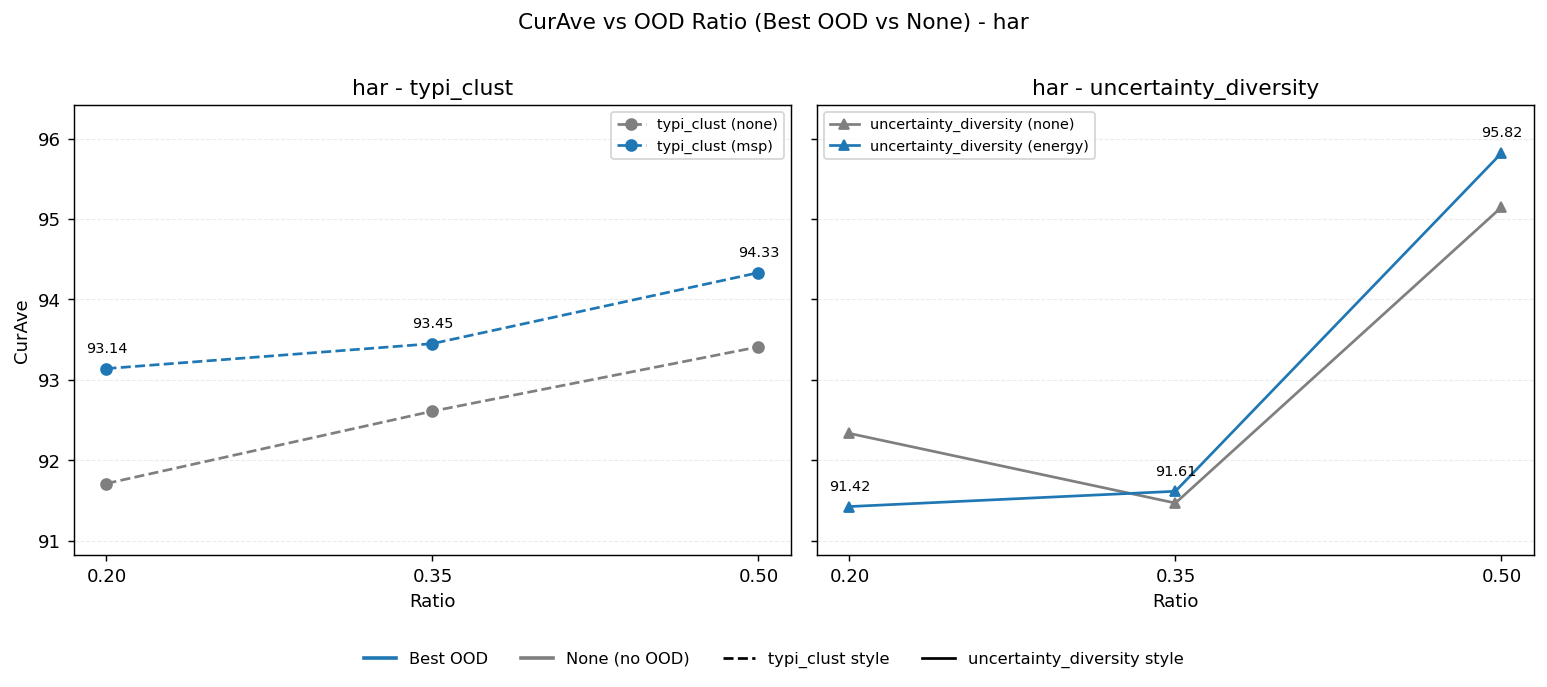

Saved result/plots/curave_ood_compare_split\CurAve_OOD_Comparison_har_split.png (best typi_clust OOD=msp, best uncertainty OOD=energy)


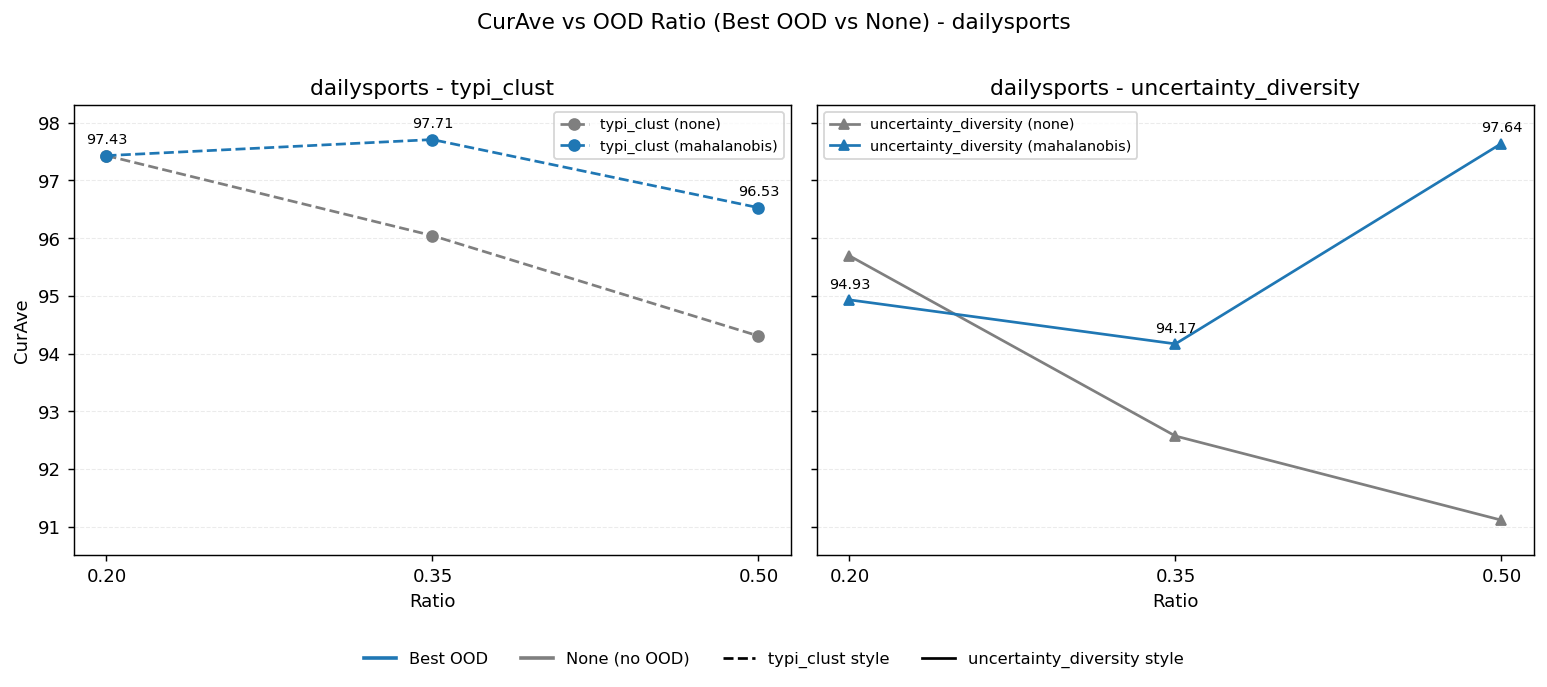

Saved result/plots/curave_ood_compare_split\CurAve_OOD_Comparison_dailysports_split.png (best typi_clust OOD=mahalanobis, best uncertainty OOD=mahalanobis)


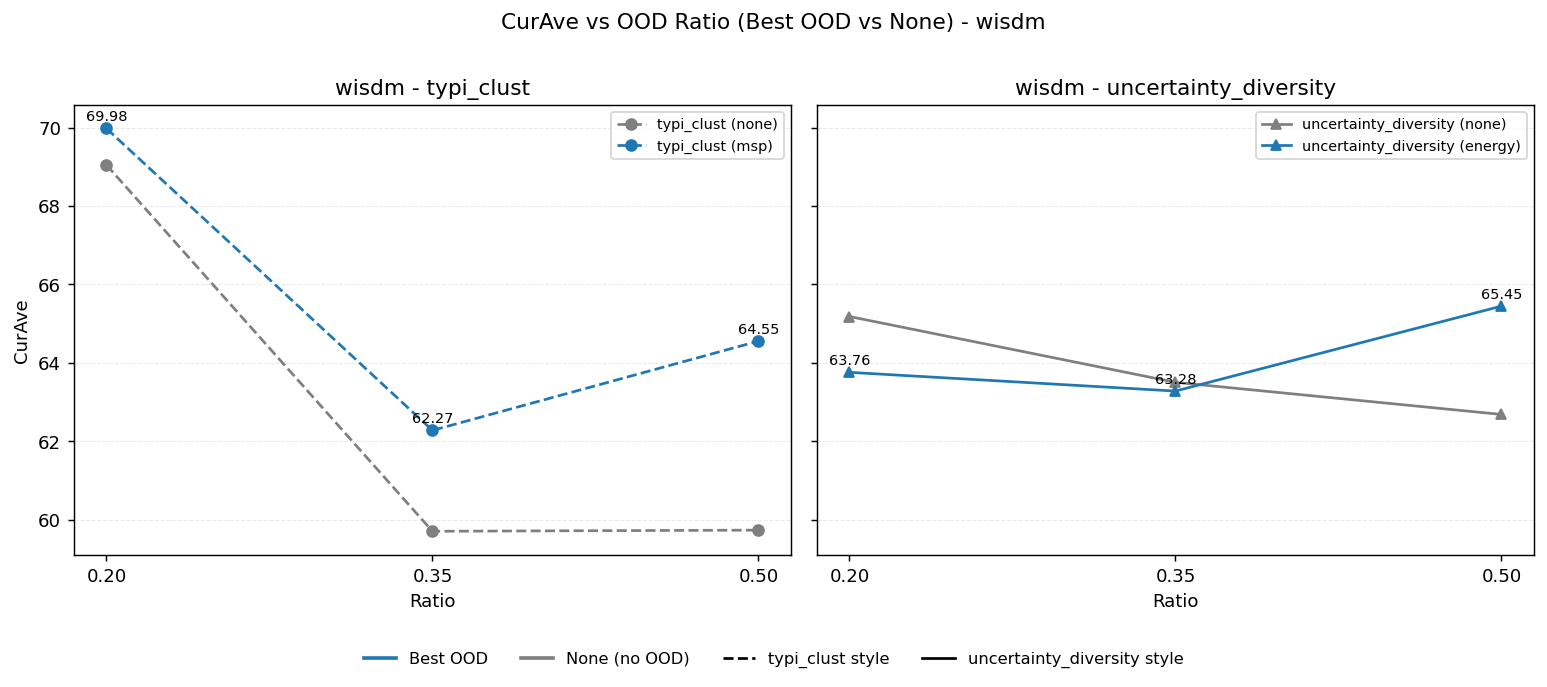

Saved result/plots/curave_ood_compare_split\CurAve_OOD_Comparison_wisdm_split.png (best typi_clust OOD=msp, best uncertainty OOD=energy)


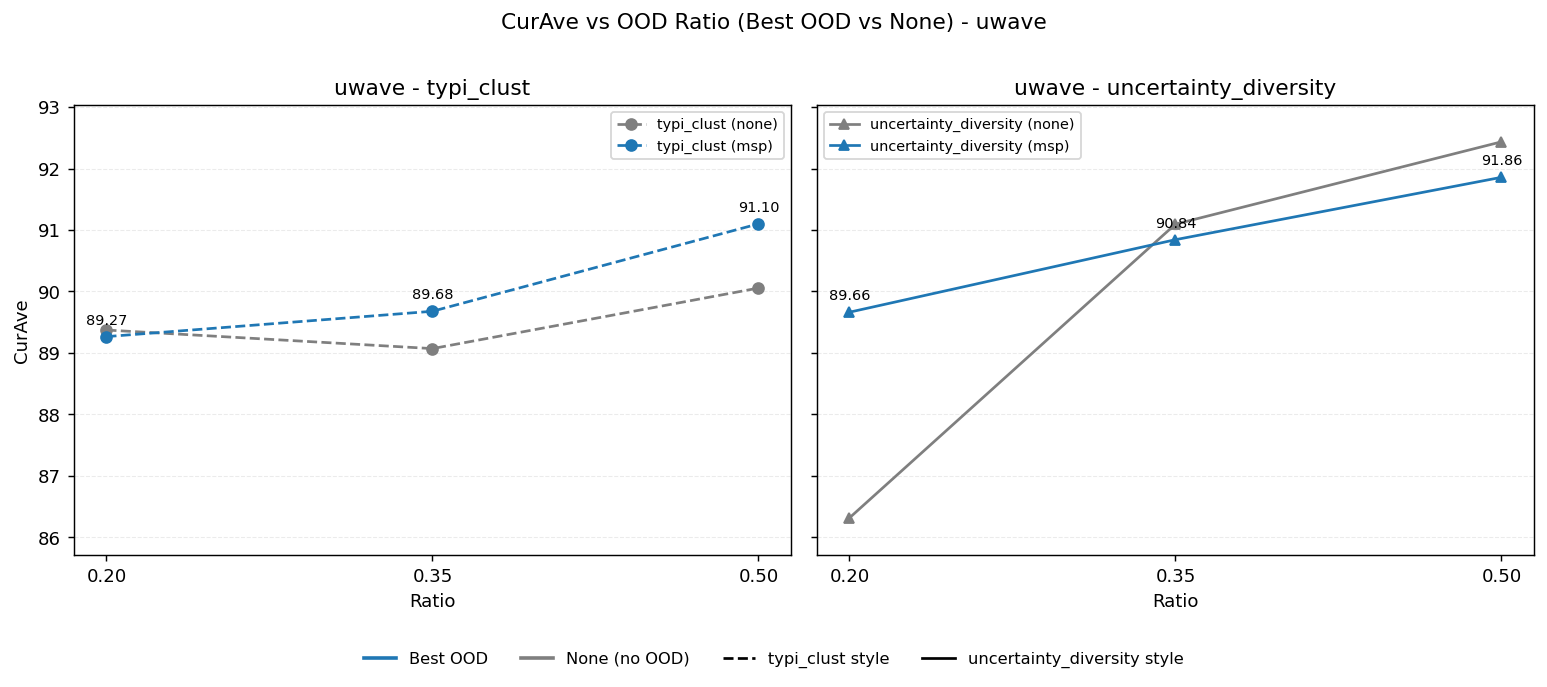

Saved result/plots/curave_ood_compare_split\CurAve_OOD_Comparison_uwave_split.png (best typi_clust OOD=msp, best uncertainty OOD=msp)


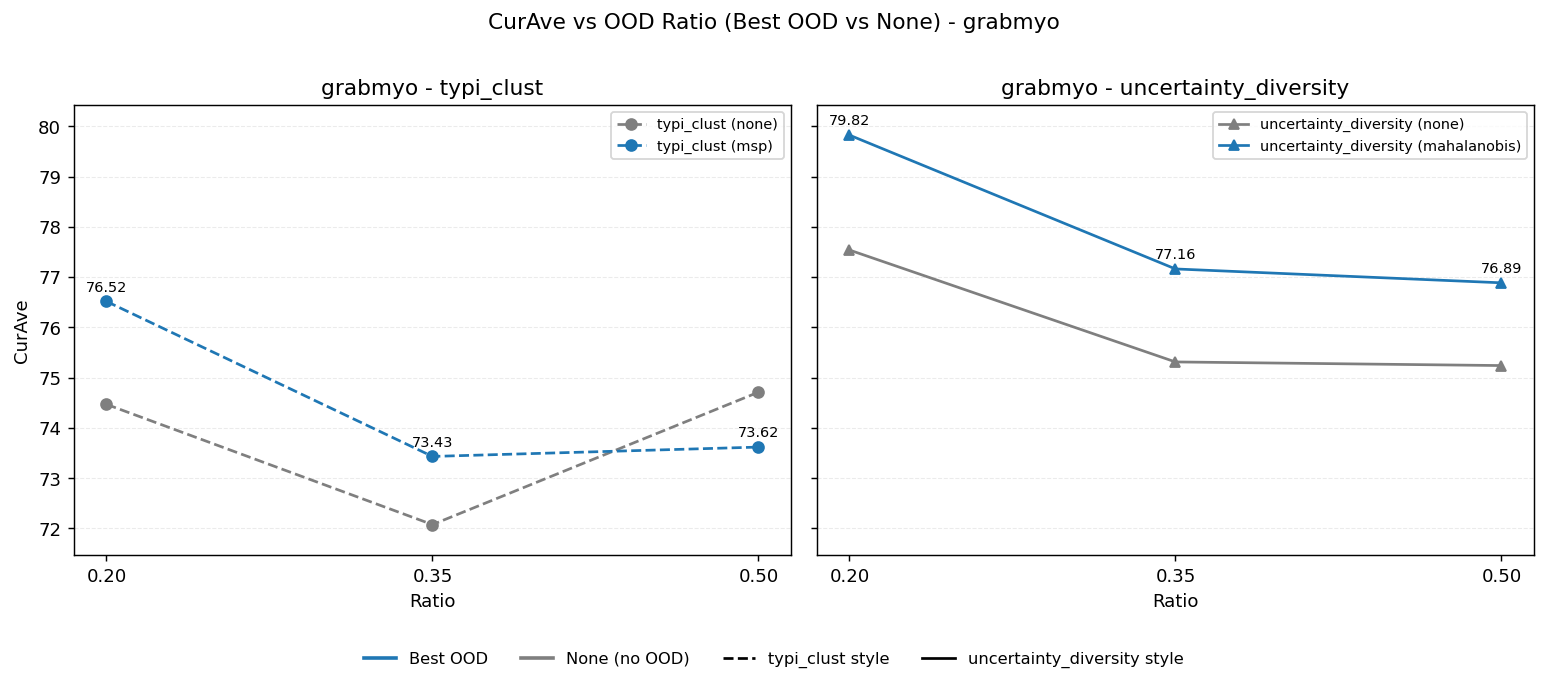

Saved result/plots/curave_ood_compare_split\CurAve_OOD_Comparison_grabmyo_split.png (best typi_clust OOD=msp, best uncertainty OOD=mahalanobis)


In [13]:
# ...existing code...

def plot_curave_comparison_split_axes(curave_sheets, datasets=('har','dailysports','wisdm','uwave','grabmyo'),
                                      ratios=(0.2,0.35,0.5), save_dir="result/plots/curave_ood_compare_split",
                                      min_padding=0.6, min_span=5.0):
    os.makedirs(save_dir, exist_ok=True)
    for ds in datasets:
        series_by_ratio = extract_curave(curave_sheets, ds, ratios)
        if not series_by_ratio:
            print(f"Skip {ds}: no data")
            continue

        best_tc = pick_best_ood(series_by_ratio, 'typi_clust')
        best_ud = pick_best_ood(series_by_ratio, 'uncertainty_diversity')

        r_sorted, tc_none, tc_best = build_lines(series_by_ratio, 'typi_clust', best_tc)
        _,        ud_none, ud_best = build_lines(series_by_ratio, 'uncertainty_diversity', best_ud)

        fig, axes = plt.subplots(1, 2, figsize=(12,5), dpi=130, sharey=True)
        color_none = '#7f7f7f'
        color_ood  = '#1f77b4'

        def apply_zoom(ax, vals):
            vals = np.array(vals, dtype=float)
            vals = vals[np.isfinite(vals)]
            if vals.size:
                vmin, vmax = float(vals.min()), float(vals.max())
                span = vmax - vmin
                if span < min_span:
                    center = (vmin + vmax)/2
                    half = max(min_span/2, span/2 + min_padding)
                    vmin, vmax = center - half, center + half
                else:
                    vmin -= min_padding
                    vmax += min_padding
                vmin = max(0, vmin)
                vmax = min(100, vmax)
                if vmin == vmax:
                    vmax = min(100, vmin + 1.0)
                ax.set_ylim(vmin, vmax)

        # Left: typi_clust
        ax = axes[0]
        ax.plot(r_sorted, tc_none, '--o', color=color_none, label='typi_clust (none)')
        ax.plot(r_sorted, tc_best, '--o', color=color_ood,  label=f"typi_clust ({best_tc})")
        for x,y in zip(r_sorted, tc_best):
            if np.isfinite(y):
                ax.text(x, y+0.2, f"{y:.2f}", ha='center', fontsize=8)
        ax.set_title(f"{ds} - typi_clust")
        ax.set_xlabel("Ratio")
        ax.set_ylabel("CurAve")
        ax.set_xticks(r_sorted)
        ax.set_xticklabels([f"{r:.2f}" for r in r_sorted])
        ax.grid(alpha=0.25, axis='y', linestyle='--', linewidth=0.6)
        apply_zoom(ax, tc_none + tc_best + ud_none + ud_best)
        ax.legend(fontsize=8, loc='best')

        # Right: uncertainty_diversity
        ax = axes[1]
        ax.plot(r_sorted, ud_none, '-^', color=color_none, label='uncertainty_diversity (none)')
        ax.plot(r_sorted, ud_best, '-^', color=color_ood,  label=f"uncertainty_diversity ({best_ud})")
        for x,y in zip(r_sorted, ud_best):
            if np.isfinite(y):
                ax.text(x, y+0.2, f"{y:.2f}", ha='center', fontsize=8)
        ax.set_title(f"{ds} - uncertainty_diversity")
        ax.set_xlabel("Ratio")
        ax.set_xticks(r_sorted)
        ax.set_xticklabels([f"{r:.2f}" for r in r_sorted])
        ax.grid(alpha=0.25, axis='y', linestyle='--', linewidth=0.6)
        ax.legend(fontsize=8, loc='best')

        # Super title + style legend
        fig.suptitle(f"CurAve vs OOD Ratio (Best OOD vs None) - {ds}", fontsize=12)
        # Add a figure-level legend explaining color meaning
        fig.legend(
            handles=[
                plt.Line2D([0],[0], color=color_ood,  lw=2, label='Best OOD'),
                plt.Line2D([0],[0], color=color_none,lw=2, label='None (no OOD)'),
                plt.Line2D([0],[0], color='black', linestyle='--', label='typi_clust style'),
                plt.Line2D([0],[0], color='black', linestyle='-',  label='uncertainty_diversity style')
            ],
            loc='lower center', ncol=4, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.05)
        )

        plt.tight_layout(rect=(0,0.03,1,0.97))
        out_path = os.path.join(save_dir, f"CurAve_OOD_Comparison_{ds}_split.png")
        plt.savefig(out_path, bbox_inches='tight')
        plt.show()
        print(f"Saved {out_path} (best typi_clust OOD={best_tc}, best uncertainty OOD={best_ud})")

# Run new split-axes plotting
plot_curave_comparison_split_axes(curave_sheets)
# ...existing code...